# ***EDA ERA5 Data***

## Importacion de librerias

In [36]:
import os
import s3fs
import xarray as xr
from dotenv import load_dotenv
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import contextily as ctx
import pyproj
from matplotlib.colors import Normalize
import zarr
import tempfile
import os
import shutil

## Configuracción del entorno

In [2]:
load_dotenv()

WASABI_CONFIG = {
    'client_kwargs': {
        'endpoint_url': 'https://s3.wasabisys.com'
    },
    'key': os.getenv('WASABI_ACCESS_KEY'),
    'secret': os.getenv('WASABI_SECRET_KEY')
}

BUCKET = os.getenv('WASABI_BUCKET')

fs = s3fs.S3FileSystem(**WASABI_CONFIG)

In [3]:
files = fs.glob(
    f"{BUCKET}/GeoVision/ERA5prueba/*.nc"
)


print(f"Archivos encontrados: {len(files)}")

Archivos encontrados: 60


In [4]:
# Ordenar
files = sorted(files)

print(files[:3])


['data-geo-raw/GeoVision/ERA5prueba/ERA5_Cali_2020_01.nc', 'data-geo-raw/GeoVision/ERA5prueba/ERA5_Cali_2020_02.nc', 'data-geo-raw/GeoVision/ERA5prueba/ERA5_Cali_2020_03.nc']


## Carga de datos

In [5]:
# ── Abrir archivos remotos con progreso ─────────────────
open_files = []

print("\nAbriendo archivos NetCDF remotos...\n")

for i, file in enumerate(tqdm(files, desc="Archivos abiertos")):

    try:

        print(f"\n[{i+1}/{len(files)}]")
        print(f"Archivo: {file}")

        f = fs.open(file, mode='rb')

        open_files.append(f)

        print("✓ Archivo agregado correctamente")

    except Exception as e:

        print(f"✗ Error abriendo archivo:")
        print(file)
        print(str(e))

print("\nTodos los archivos fueron abiertos.\n")

# ── Abrir dataset ERA5 ──────────────────────────────────
print("Iniciando open_mfdataset...\n")

inicio = time.time()

ds = xr.open_mfdataset(
    open_files,
    engine="h5netcdf",
    combine="by_coords",
    parallel=True,
    chunks={
        "time": 24
    }
)

fin = time.time()

print("\n✓ Dataset ERA5 cargado correctamente")
print(f"Tiempo total: {(fin - inicio):.2f} segundos\n")

# ── Información del dataset ─────────────────────────────
print(ds)


Abriendo archivos NetCDF remotos...



Archivos abiertos: 100%|██████████| 60/60 [00:00<00:00, 2942.30it/s]


[1/60]
Archivo: data-geo-raw/GeoVision/ERA5prueba/ERA5_Cali_2020_01.nc
✓ Archivo agregado correctamente

[2/60]
Archivo: data-geo-raw/GeoVision/ERA5prueba/ERA5_Cali_2020_02.nc
✓ Archivo agregado correctamente

[3/60]
Archivo: data-geo-raw/GeoVision/ERA5prueba/ERA5_Cali_2020_03.nc
✓ Archivo agregado correctamente

[4/60]
Archivo: data-geo-raw/GeoVision/ERA5prueba/ERA5_Cali_2020_04.nc
✓ Archivo agregado correctamente

[5/60]
Archivo: data-geo-raw/GeoVision/ERA5prueba/ERA5_Cali_2020_05.nc
✓ Archivo agregado correctamente

[6/60]
Archivo: data-geo-raw/GeoVision/ERA5prueba/ERA5_Cali_2020_06.nc
✓ Archivo agregado correctamente

[7/60]
Archivo: data-geo-raw/GeoVision/ERA5prueba/ERA5_Cali_2020_07.nc
✓ Archivo agregado correctamente

[8/60]
Archivo: data-geo-raw/GeoVision/ERA5prueba/ERA5_Cali_2020_08.nc
✓ Archivo agregado correctamente

[9/60]
Archivo: data-geo-raw/GeoVision/ERA5prueba/ERA5_Cali_2020_09.nc
✓ Archivo agregado correctamente

[10/60]
Archivo: data-geo-raw/GeoVision/ERA5prueba/ERA


✓ Dataset ERA5 cargado correctamente
Tiempo total: 19.61 segundos

<xarray.Dataset> Size: 12MB
Dimensions:     (valid_time: 43848, latitude: 4, longitude: 3)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 351kB 2020-01-01 ... 2024-12-31T2...
    expver      (valid_time) <U4 702kB dask.array<chunksize=(744,), meta=np.ndarray>
  * latitude    (latitude) float64 32B 3.75 3.5 3.25 3.0
  * longitude   (longitude) float64 24B -76.75 -76.5 -76.25
    number      int64 8B 0
Data variables:
    t2m         (valid_time, latitude, longitude) float32 2MB dask.array<chunksize=(744, 4, 3), meta=np.ndarray>
    u10         (valid_time, latitude, longitude) float32 2MB dask.array<chunksize=(744, 4, 3), meta=np.ndarray>
    v10         (valid_time, latitude, longitude) float32 2MB dask.array<chunksize=(744, 4, 3), meta=np.ndarray>
    blh         (valid_time, latitude, longitude) float32 2MB dask.array<chunksize=(744, 4, 3), meta=np.ndarray>
    d2m         (valid_time, latitude, longitude) 

## Verificación del dataset

In [6]:
print("\nDimensiones:")
print(ds.dims)

print("\nVariables:")
print(list(ds.data_vars))

print("\nPrimeros timestamps:")
print(ds.valid_time[:10])


Dimensiones:
FrozenMappingWarningOnValuesAccess({'valid_time': 43848, 'latitude': 4, 'longitude': 3})

Variables:
['t2m', 'u10', 'v10', 'blh', 'd2m']

Primeros timestamps:
<xarray.DataArray 'valid_time' (valid_time: 10)> Size: 80B
array(['2020-01-01T00:00:00.000000000', '2020-01-01T01:00:00.000000000',
       '2020-01-01T02:00:00.000000000', '2020-01-01T03:00:00.000000000',
       '2020-01-01T04:00:00.000000000', '2020-01-01T05:00:00.000000000',
       '2020-01-01T06:00:00.000000000', '2020-01-01T07:00:00.000000000',
       '2020-01-01T08:00:00.000000000', '2020-01-01T09:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 80B 2020-01-01 ... 2020-01-01T09:...
    expver      (valid_time) <U4 160B dask.array<chunksize=(10,), meta=np.ndarray>
    number      int64 8B 0
Attributes:
    long_name:      time
    standard_name:  time


In [7]:
print("Coordenadas de Latitud:")
print(ds.latitude.values)
print("\nCoordenadas de Longitud:")
print(ds.longitude.values)

Coordenadas de Latitud:
[3.75 3.5  3.25 3.  ]

Coordenadas de Longitud:
[-76.75 -76.5  -76.25]


### ***Verificacion de la versión del experimento***

In [8]:
print(np.unique(ds['expver'].values))

['0001']


In [9]:
expected = pd.date_range('2020-01-01', '2024-12-31 23:00', freq='1h')
actual = pd.DatetimeIndex(ds['valid_time'].values)
faltantes = expected.difference(actual)
print(f"Huecos: {len(faltantes)}")

Huecos: 0


In [10]:
# Rangos esperados para Cali (clima tropical)
assert ds['t2m'].min() > 273, "Temperatura sospechosamente baja"
assert ds['t2m'].max() < 320, "Temperatura sospechosamente alta"
assert ds['blh'].min() >= 0,  "BLH negativo — error grave"
assert (ds['blh'] < 5000).all(), "BLH > 5km es inusual en zona tropical"

In [11]:
for var in ['t2m', 'u10', 'v10', 'blh', 'd2m']:
    n = ds[var].isnull().sum().values
    print(f"{var}: {n} NaNs")

t2m: 0 NaNs
u10: 0 NaNs
v10: 0 NaNs
blh: 0 NaNs
d2m: 0 NaNs


In [12]:
stats = {}
for var in ['t2m', 'u10', 'v10', 'blh', 'd2m']:
    stats[var] = {
        'min': ds[var].min().values,
        'max': ds[var].max().values,
        'mean': ds[var].mean().values,
        'std': ds[var].std().values
    }

df_stats = pd.DataFrame(stats).T
print(df_stats)

            min        max         mean         std
t2m   279.96558   307.2085     293.1245   3.1780543
u10  -3.0934296  3.4939728   0.36025676   0.8812349
v10  -3.7135315  2.6068726  -0.43661323  0.72944224
blh    10.33774  2566.3694    256.97955    266.4656
d2m   275.69165  300.48022     290.5274    2.514697


In [13]:
ds['t2m'] = ds['t2m'] - 273.15
ds['d2m'] = ds['d2m'] - 273.15

In [14]:
min_val = ds['t2m'].min().values
max_val = ds['t2m'].max().values
print(f"{var}: min={min_val:.2f}, max={max_val:.2f}")

d2m: min=6.82, max=34.06


In [15]:
# ── 1. Calcular velocidad del viento ──────────────────
ds["wind_speed"] = np.sqrt(
    ds["u10"]**2 + ds["v10"]**2
)

# Metadata opcional
ds["wind_speed"].attrs = {
    "long_name": "Wind Speed at 10m",
    "units": "m/s"
}

In [16]:
# Humedad relativa con fórmula de Magnus
# RH = 100 * exp((17.625 * d2m) / (243.04 + d2m)) / exp((17.625 * t2m) / (243.04 + t2m))

ds['rh'] = 100 * (
    np.exp((17.625 * ds['d2m']) / (243.04 + ds['d2m'])) /
    np.exp((17.625 * ds['t2m']) / (243.04 + ds['t2m']))
)

# Verificar que esté en rango físico válido (0-100%)
print("RH min:", float(ds['rh'].min()))
print("RH max:", float(ds['rh'].max()))
print("RH media:", float(ds['rh'].mean()))

RH min: 24.637683868408203
RH max: 100.01862335205078
RH media: 85.7898941040039


In [17]:
ds['rh'] = ds['rh'].clip(0, 100)

In [18]:
# Verificar que esté en rango físico válido (0-100%)
print("RH min:", float(ds['rh'].min()))
print("RH max:", float(ds['rh'].max()))
print("RH media:", float(ds['rh'].mean()))

RH min: 24.637683868408203
RH max: 100.0
RH media: 85.78988647460938


In [19]:
print("\nVariables:")
print(list(ds.data_vars))


Variables:
['t2m', 'u10', 'v10', 'blh', 'd2m', 'wind_speed', 'rh']


## Dataset consolidado

In [20]:
vars_seleccionadas = ['t2m', 'wind_speed', 'blh', 'rh']
ds_consolidado = ds[vars_seleccionadas].copy()

In [21]:
print(ds_consolidado)

<xarray.Dataset> Size: 9MB
Dimensions:     (valid_time: 43848, latitude: 4, longitude: 3)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 351kB 2020-01-01 ... 2024-12-31T2...
    expver      (valid_time) <U4 702kB dask.array<chunksize=(744,), meta=np.ndarray>
  * latitude    (latitude) float64 32B 3.75 3.5 3.25 3.0
  * longitude   (longitude) float64 24B -76.75 -76.5 -76.25
    number      int64 8B 0
Data variables:
    t2m         (valid_time, latitude, longitude) float32 2MB dask.array<chunksize=(744, 4, 3), meta=np.ndarray>
    wind_speed  (valid_time, latitude, longitude) float32 2MB dask.array<chunksize=(744, 4, 3), meta=np.ndarray>
    blh         (valid_time, latitude, longitude) float32 2MB dask.array<chunksize=(744, 4, 3), meta=np.ndarray>
    rh          (valid_time, latitude, longitude) float32 2MB dask.array<chunksize=(744, 4, 3), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather For

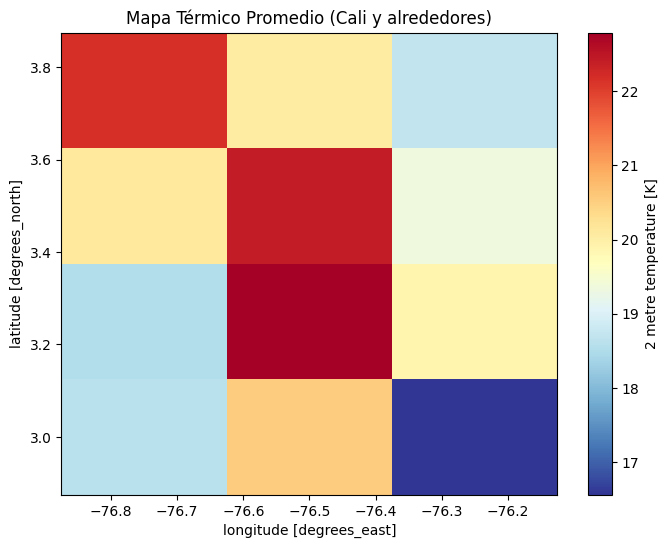

In [22]:
# ── 3. Mapa de calor de variables climáticas (Promedio espacial) ──
# ¿Qué zonas de tu recuadro son más calientes?
mapa_temp = ds['t2m'].mean(dim='valid_time')
mapa_temp.plot(figsize=(8, 6), cmap='RdYlBu_r')
plt.title("Mapa Térmico Promedio (Cali y alrededores)")
plt.show()

In [23]:
lats_objetivo = np.arange(3.00, 3.75, 0.005)
lons_objetivo = np.arange(-76.75, -76.25, 0.005)

era5_interpolado = ds_consolidado.interp(
    latitude=lats_objetivo,
    longitude=lons_objetivo,
    method='linear'
)

In [24]:
ds_cali = era5_interpolado.sel(
    latitude=slice(3.20, 3.75),
    longitude=slice(-76.75, -76.30)
)

print('Dimensiones tras recorte:')
print(dict(ds_cali.dims))
print(f"Lat: {float(ds_cali.latitude.min()):.3f} → {float(ds_cali.latitude.max()):.3f}")
print(f"Lon: {float(ds_cali.longitude.min()):.3f} → {float(ds_cali.longitude.max()):.3f}")

Dimensiones tras recorte:
{'valid_time': 43848, 'latitude': 109, 'longitude': 91}
Lat: 3.205 → 3.745
Lon: -76.750 → -76.300


C:\Users\valen\AppData\Local\Temp\ipykernel_34684\857626112.py:7: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(dict(ds_cali.dims))


In [25]:
print(ds_cali)

<xarray.Dataset> Size: 7GB
Dimensions:     (valid_time: 43848, latitude: 109, longitude: 91)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 351kB 2020-01-01 ... 2024-12-31T2...
    expver      (valid_time) <U4 702kB dask.array<chunksize=(744,), meta=np.ndarray>
  * latitude    (latitude) float64 872B 3.205 3.21 3.215 ... 3.735 3.74 3.745
  * longitude   (longitude) float64 728B -76.75 -76.75 -76.74 ... -76.31 -76.3
    number      int64 8B 0
Data variables:
    t2m         (valid_time, latitude, longitude) float32 2GB dask.array<chunksize=(744, 109, 91), meta=np.ndarray>
    wind_speed  (valid_time, latitude, longitude) float32 2GB dask.array<chunksize=(744, 109, 91), meta=np.ndarray>
    blh         (valid_time, latitude, longitude) float32 2GB dask.array<chunksize=(744, 109, 91), meta=np.ndarray>
    rh          (valid_time, latitude, longitude) float32 2GB dask.array<chunksize=(744, 109, 91), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDes

In [26]:
ds_diario = xr.merge([
    ds_cali[['t2m']].resample(valid_time='1D').mean(),
    ds_cali[['wind_speed']].resample(valid_time='1D').mean(),
    ds_cali[['blh']].resample(valid_time='1D').max(),
    ds_cali[['rh']].resample(valid_time='1D').mean()
])

print(dict(ds_diario.dims))
print(ds_diario)

{'valid_time': 1827, 'latitude': 109, 'longitude': 91}
<xarray.Dataset> Size: 290MB
Dimensions:     (valid_time: 1827, latitude: 109, longitude: 91)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 15kB 2020-01-01 ... 2024-12-31
  * latitude    (latitude) float64 872B 3.205 3.21 3.215 ... 3.735 3.74 3.745
  * longitude   (longitude) float64 728B -76.75 -76.75 -76.74 ... -76.31 -76.3
    number      int64 8B 0
Data variables:
    t2m         (valid_time, latitude, longitude) float32 72MB dask.array<chunksize=(1, 109, 91), meta=np.ndarray>
    wind_speed  (valid_time, latitude, longitude) float32 72MB dask.array<chunksize=(1, 109, 91), meta=np.ndarray>
    blh         (valid_time, latitude, longitude) float32 72MB dask.array<chunksize=(1, 109, 91), meta=np.ndarray>
    rh          (valid_time, latitude, longitude) float32 72MB dask.array<chunksize=(1, 109, 91), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-R

C:\Users\valen\AppData\Local\Temp\ipykernel_34684\2082412356.py:8: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(dict(ds_diario.dims))


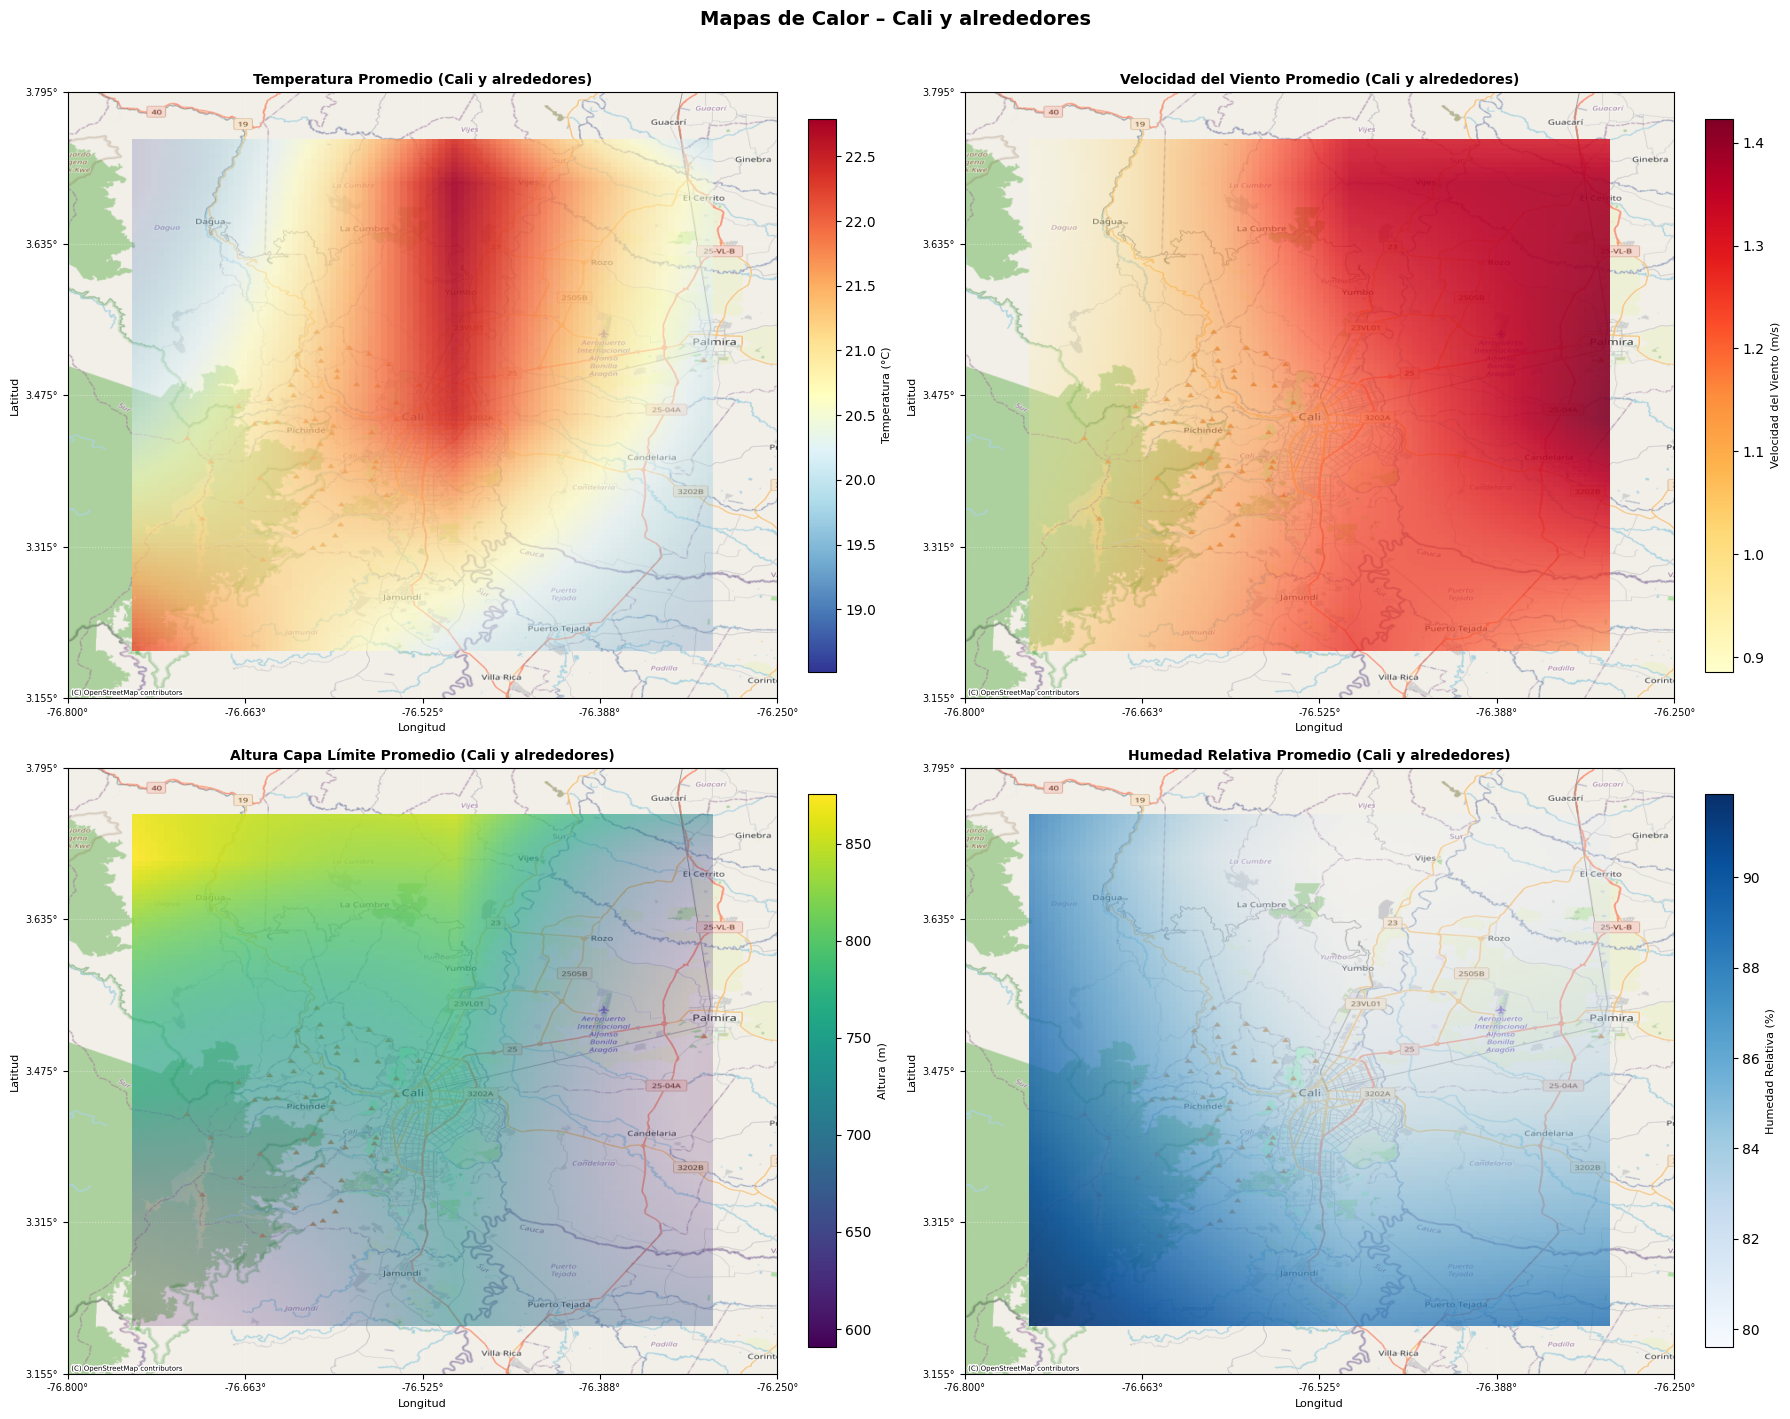

In [27]:
# ── Configuración de variables ───────────────────────────────────────────────
variables = ['t2m', 'wind_speed', 'blh', 'rh']

titles = {
    't2m':       'Temperatura Promedio (Cali y alrededores)',
    'wind_speed':'Velocidad del Viento Promedio (Cali y alrededores)',
    'blh':       'Altura Capa Límite Promedio (Cali y alrededores)',
    'rh':        'Humedad Relativa Promedio (Cali y alrededores)',
}

clabels = {
    't2m':       'Temperatura (°C)',
    'wind_speed':'Velocidad del Viento (m/s)',
    'blh':       'Altura (m)',
    'rh':        'Humedad Relativa (%)',
}

cmaps = {
    't2m':       plt.cm.RdYlBu_r,
    'wind_speed':plt.cm.YlOrRd,
    'blh':       plt.cm.viridis,
    'rh':        plt.cm.Blues,
}

# ── Crear figura 2×2 ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes_flat = axes.flatten()

# ── Transformadores CRS ───────────────────────────────────────────────────────
transformer     = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
inv_transformer = pyproj.Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True)

buffer_deg = 0.05

# ── Iterar sobre cada variable ────────────────────────────────────────────────
for ax, var in zip(axes_flat, variables):

    # Promedio temporal
    mapa = ds_diario[var].mean(dim='valid_time')

    lats   = mapa.latitude.values
    lons   = mapa.longitude.values
    values = mapa.values

    # Límites geográficos → Web Mercator
    lon_min, lon_max = lons.min(), lons.max()
    lat_min, lat_max = lats.min(), lats.max()

    west,  south  = transformer.transform(lon_min - buffer_deg, lat_min - buffer_deg)
    east,  north  = transformer.transform(lon_max + buffer_deg, lat_max + buffer_deg)

    west_data, south_data = transformer.transform(lon_min, lat_min)
    east_data, north_data = transformer.transform(lon_max, lat_max)

    # Colormap y normalización
    cmap = cmaps[var]
    norm = Normalize(vmin=np.nanmin(values), vmax=np.nanmax(values))

    rgba_heat = cmap(norm(values))

    alpha_matrix = np.clip(norm(values) * 0.85 + 0.15, 0.20, 0.90)
    rgba_heat[..., 3] = alpha_matrix

    # Mapa base
    ax.set_xlim(west, east)
    ax.set_ylim(south, north)

    ctx.add_basemap(
        ax,
        crs="EPSG:3857",
        source=ctx.providers.OpenStreetMap.Mapnik,
        zoom='auto',
        attribution_size=5
    )

    # Superponer heatmap
    ax.imshow(
        rgba_heat,
        extent=[west_data, east_data, south_data, north_data],
        origin='upper',
        aspect='auto',
        zorder=2
    )

    # Ejes en grados
    x_ticks_merc = np.linspace(west, east, 5)
    y_ticks_merc = np.linspace(south, north, 5)

    x_ticks_deg = [inv_transformer.transform(x, south)[0] for x in x_ticks_merc]
    y_ticks_deg = [inv_transformer.transform(west, y)[1]  for y in y_ticks_merc]

    ax.set_xticks(x_ticks_merc)
    ax.set_xticklabels([f"{d:.3f}°" for d in x_ticks_deg], fontsize=7)

    ax.set_yticks(y_ticks_merc)
    ax.set_yticklabels([f"{d:.3f}°" for d in y_ticks_deg], fontsize=7)

    # Títulos y etiquetas
    ax.set_title(titles[var], fontsize=10, fontweight='bold')
    ax.set_xlabel("Longitud", fontsize=8)
    ax.set_ylabel("Latitud",  fontsize=8)

    ax.grid(True, linestyle=':', alpha=0.4, color='white', zorder=3)

    # Barra de color
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.036, pad=0.04)
    cbar.set_label(clabels[var], fontsize=8)

plt.suptitle("Mapas de Calor – Cali y alrededores", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

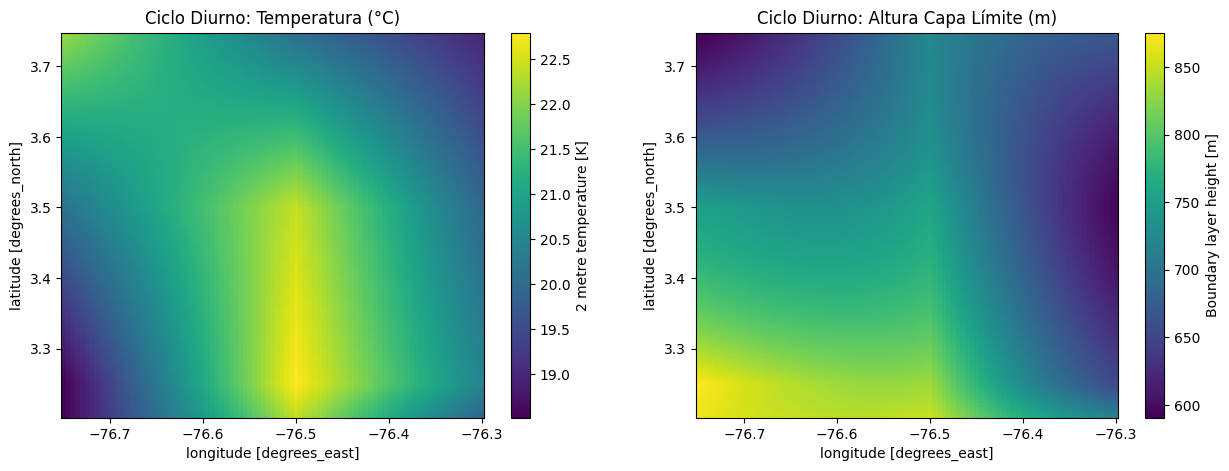

In [28]:
# ── 1. Ciclo Diurno (El poder de la periodicidad horaria) ──
# Agrupamos por la hora del día (0-23) para ver el comportamiento típico diario
ciclo_diurno = ds_diario.groupby(ds_diario.valid_time.dt.hour).mean()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ciclo_diurno['t2m'].plot(ax=axes[0])
axes[0].set_title("Ciclo Diurno: Temperatura (°C)")
ciclo_diurno['blh'].plot(ax=axes[1])
axes[1].set_title("Ciclo Diurno: Altura Capa Límite (m)")
plt.show()

### 🌟Ver la distribución de todas las variables🌟

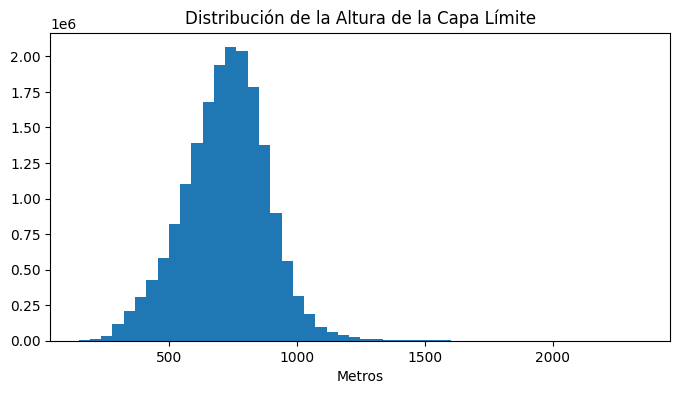

In [29]:
# ── 4. Histograma de BLH (Distribución) ──
# Esto es vital para entender la estabilidad atmosférica
ds_diario['blh'].plot.hist(bins=50, figsize=(8, 4))
plt.title("Distribución de la Altura de la Capa Límite")
plt.xlabel("Metros")
plt.show()

###

In [30]:
# Variables a procesar
vars = ['t2m', 'wind_speed', 'blh', 'rh']

# 1) Media espacial (lat, lon)
spatial_mean = xr.Dataset({v: ds_diario[v].mean(dim=['latitude', 'longitude']) for v in vars})

# 2) Resample diario y mensual (usa 'valid_time' como coordenada temporal)
daily = spatial_mean
monthly = spatial_mean.resample(valid_time='1ME').mean()  # '1ME' = month end

# 3) Convertir a DataFrame (cada columna = variable)
daily_df = pd.DataFrame({v: daily[v].to_series() for v in vars})
monthly_df = pd.DataFrame({v: monthly[v].to_series() for v in vars})

# 4) Mostrar resumen y primeras filas
print("Daily (head):")
print(daily_df.head())
print("\nMonthly (head):")
print(monthly_df.head())

Daily (head):
                  t2m  wind_speed         blh         rh
valid_time                                              
2020-01-01  20.758528    1.038618  858.464539  87.303467
2020-01-02  21.249350    1.017517  928.419495  88.573837
2020-01-03  21.607786    1.134418  844.068115  84.679115
2020-01-04  21.186523    1.212759  889.799683  84.994804
2020-01-05  21.170424    1.235844  849.329773  86.577553

Monthly (head):
                  t2m  wind_speed         blh         rh
valid_time                                              
2020-01-31  21.257069    1.227848  823.429138  85.720390
2020-02-29  21.643167    1.249296  807.274841  85.427170
2020-03-31  21.609497    1.202251  808.019775  85.059036
2020-04-30  21.513824    1.175141  687.773682  86.388718
2020-05-31  21.756907    1.235570  664.614807  86.005180


### 🌟Hacer el mismo grafico para todas las variables y para cada una hacer dos graficas (una de daily y otro de monthly)🌟

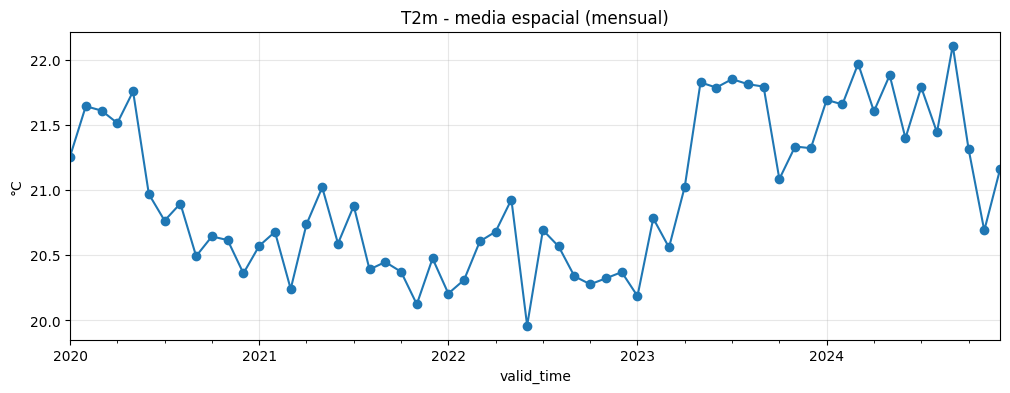

In [31]:
# 5) Graficar ejemplo: t2m mensual
plt.figure(figsize=(12,4))
monthly_df['t2m'].plot(marker='o', linestyle='-')
plt.title("T2m - media espacial (mensual)")
plt.ylabel("°C")
plt.grid(alpha=0.3)
plt.show()

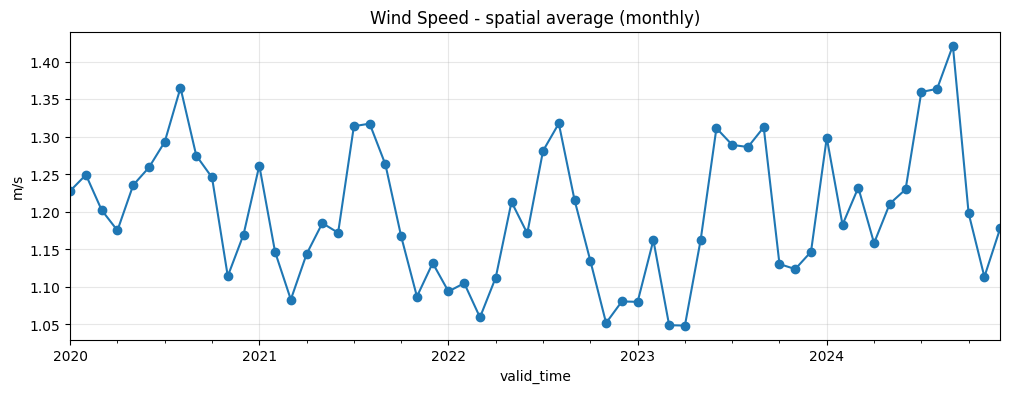

In [32]:
plt.figure(figsize=(12,4))
monthly_df['wind_speed'].plot(marker='o', linestyle='-')
plt.title("Wind Speed - spatial average (monthly)")
plt.ylabel("m/s")
plt.grid(alpha=0.3)
plt.show()

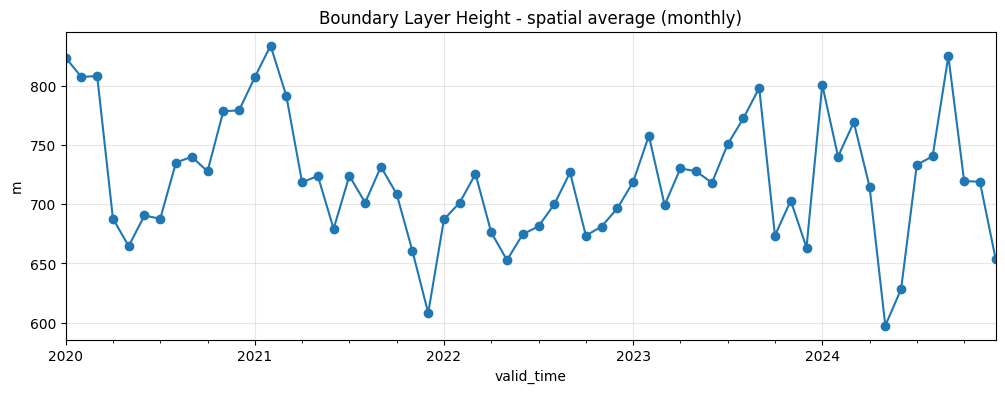

In [33]:
plt.figure(figsize=(12,4))
monthly_df['blh'].plot(marker='o', linestyle='-')
plt.title("Boundary Layer Height - spatial average (monthly)")
plt.ylabel("m")
plt.grid(alpha=0.3)
plt.show()

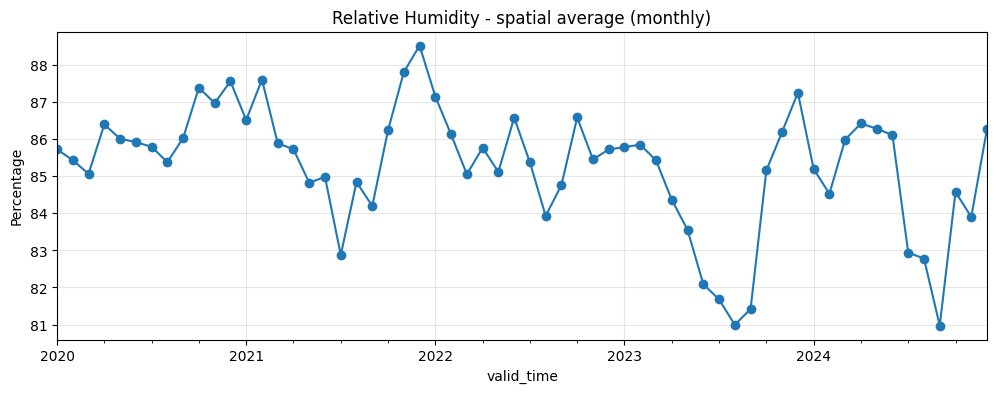

In [34]:
plt.figure(figsize=(12,4))
monthly_df['rh'].plot(marker='o', linestyle='-')
plt.title("Relative Humidity - spatial average (monthly)")
plt.ylabel("Percentage")
plt.grid(alpha=0.3)
plt.show()

## Subida a Wasabi

In [37]:
BUCKET_DEST = "data-geovision-clean"

# --- 2. Exportar a Zarr local (temporal) ---
ruta_zarr_local = os.path.join(tempfile.gettempdir(), 'era5_consolidado.zarr')

# Eliminar si ya existe (evita conflictos de escritura)
if os.path.exists(ruta_zarr_local):
    shutil.rmtree(ruta_zarr_local)

ds_diario.to_zarr(ruta_zarr_local, mode='w', consolidated=True)
print(f"\n✅ Zarr guardado localmente en: {ruta_zarr_local}")

# --- 3. Subir a Wasabi ---
ruta_zarr_wasabi = f's3://{BUCKET_DEST}/GeoVision_Panel/era5_consolidado.zarr'

print(f"\nSubiendo a Wasabi: {ruta_zarr_wasabi} ...")

# Recorrer todos los archivos del zarr local y subirlos
archivos_subidos = 0
for root, dirs, files in os.walk(ruta_zarr_local):
    for archivo in files:
        ruta_local_completa = os.path.join(root, archivo)
        # Construir la ruta relativa dentro del zarr
        ruta_relativa = os.path.relpath(ruta_local_completa, ruta_zarr_local)
        ruta_s3 = f'{ruta_zarr_wasabi}/{ruta_relativa}'.replace('\\', '/')
        fs.put(ruta_local_completa, ruta_s3)
        archivos_subidos += 1

print(f"✅ Subida completa: {archivos_subidos} archivos subidos")
print(f"   Ruta en Wasabi: {ruta_zarr_wasabi}")

c:\Users\valen\Desktop\proyecto3_analitica\venv\Lib\site-packages\zarr\api\asynchronous.py:231: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(



✅ Zarr guardado localmente en: C:\Users\valen\AppData\Local\Temp\era5_consolidado.zarr

Subiendo a Wasabi: s3://data-geovision-clean/GeoVision_Panel/era5_consolidado.zarr ...
✅ Subida completa: 7320 archivos subidos
   Ruta en Wasabi: s3://data-geovision-clean/GeoVision_Panel/era5_consolidado.zarr


In [38]:
# --- 4. Verificación: leer de vuelta desde Wasabi ---
print("\nVerificando lectura desde Wasabi...")
ds_verificacion = xr.open_zarr(fs.get_mapper(ruta_zarr_wasabi)).compute()
print(ds_verificacion)
print(f"\n✅ Verificación exitosa — {ds_verificacion.sizes['valid_time']} timestamps, "
      f"{len(list(ds_verificacion.data_vars))} variables")


Verificando lectura desde Wasabi...
<xarray.Dataset> Size: 290MB
Dimensions:     (valid_time: 1827, latitude: 109, longitude: 91)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 15kB 2020-01-01 ... 2024-12-31
  * latitude    (latitude) float64 872B 3.205 3.21 3.215 ... 3.735 3.74 3.745
  * longitude   (longitude) float64 728B -76.75 -76.75 -76.74 ... -76.31 -76.3
    number      int64 8B 0
Data variables:
    blh         (valid_time, latitude, longitude) float32 72MB 883.8 ... 603.9
    rh          (valid_time, latitude, longitude) float32 72MB 86.37 ... 89.26
    t2m         (valid_time, latitude, longitude) float32 72MB 18.52 ... 18.31
    wind_speed  (valid_time, latitude, longitude) float32 72MB 0.9127 ... 1.108
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather F